In [2]:
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *
import matplotlib.pyplot as plt

In [37]:
# 回路作成
circuit = Circuit('Source Follower')

# 電源（'素子名の識別子', '正極のノード名', '負極のノード名', 電圧値）
circuit.V('dd', 'vdd', circuit.gnd, 1.8@u_V)

# 正弦波入力（素子名、正極ノード、負極ノード、直流オフセット、振幅、周波数）
circuit.SinusoidalVoltageSource(
    'input', 'vin', circuit.gnd,
    dc_offset=1.0@u_V,
    offset=1.0@u_V,
    amplitude=0.3@u_V,
    frequency=100@u_Hz
)

# 簡易NMOSモデルの定義（'モデル名', '素子タイプ', 'レベル', 'パラメータ1=値1', 'パラメータ2=値2', ...）
circuit.model('nmos', 'NMOS', LEVEL=1, KP=220*10**-6, VTO=0.7@u_V, LAMBDA_=0.02)

# MOSFETを置くための関数（'素子名', 'ドレイン', 'ゲート', 'ソース', 'ボディ', model='モデル名', l=チャネル長, w=チャネル幅）
circuit.M('m1', 'vdd', 'vin', 'out', 'out', model='nmos', l=1@u_um, w=100@u_um)

# ソース側の負荷（'素子名', '接続ノード1', '接続ノード2', 抵抗値）
circuit.R('load', 'out', circuit.gnd, 1@u_MOhm)

simulator = circuit.simulator(temperature=25, nominal_temperature=25)
analysis = simulator.transient(step_time=0.1@u_ms, end_time=50@u_ms)

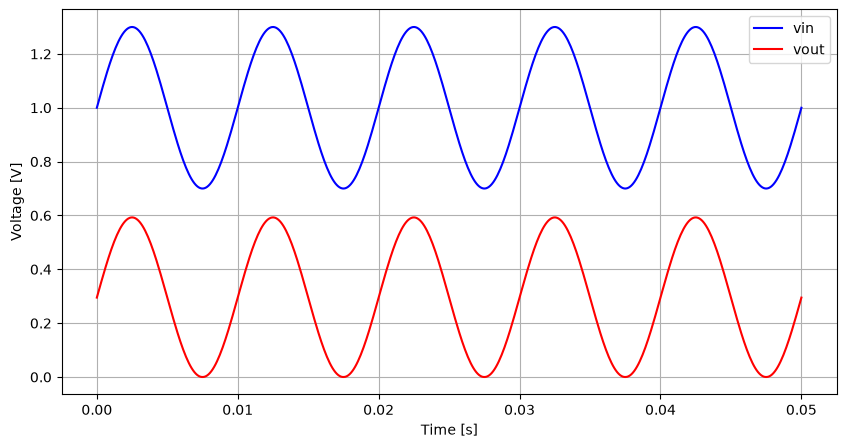

In [39]:
# 波形表示用
# ｘ軸：時間(time)、ｙ軸：電圧(vin, vout)
time = analysis.time.as_ndarray()
vin = analysis['vin'].as_ndarray()
vout = analysis['out'].as_ndarray()

plt.figure(figsize=(10, 5))
plt.plot(time, vin, label='vin', color='blue')
plt.plot(time, vout, label='vout', color='red')
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.legend()
plt.grid(True)
plt.show()

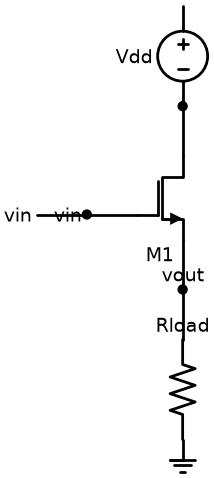

In [26]:
import schemdraw
import schemdraw.elements as elm
# import schemdraw.logic as logic

with schemdraw.Drawing() as d:
    d.config(unit=2.0)

    # NMOS（縦向き）
    m1 = d.add(elm.AnalogNFet().at((0, 1)).left().flip().label('M1', loc='bottom'))

    # ドレインをVddに接続
    d += elm.Line().at(m1.drain).up(1.0)
    d += elm.Dot()
    d += elm.SourceV().up().label('Vdd', loc='top')

    # ゲート入力 vin
    d += elm.Line().at(m1.gate).left(1.0).label('vin', loc='left')
    d += elm.Dot()
    d += elm.Line().left(1.0).label('vin', loc='left')

    # ソース出力 vout
    d += elm.Line().at(m1.source).down(1.0)
    d += elm.Dot()
    d += elm.Line().down(1.0).label('vout', loc='right')

    # ソースからGNDへ負荷抵抗
    d += elm.Resistor().down().label('Rload', loc='right')
    d += elm.Ground()

    d.draw()